##Libraries

In [58]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


##Load dataset

In [2]:
filepath = '/content/drive/MyDrive/AI ML/IRP/datasets/dataset/Bharatanatyam_Mudras'
print(os.listdir(filepath))

['Simhamukha', 'Sikhara', 'Musti', 'Pataka', 'Trisula']


In [3]:
data = []
for class_name in os.listdir(filepath):
  class_path = os.path.join(filepath, class_name)
  if os.path.isdir(class_path):
    for image in os.listdir(class_path):
      data.append([os.path.join(class_path, image),class_name])
df_mudra = pd.DataFrame(data, columns=["image_path", "class"])

print("Total images:", len(df_mudra))
df_mudra.head()

Total images: 2000


,image_path,class
0,/content/drive/MyDrive/AI ML/IRP/datasets/data...,Simhamukha
1,/content/drive/MyDrive/AI ML/IRP/datasets/data...,Simhamukha
2,/content/drive/MyDrive/AI ML/IRP/datasets/data...,Simhamukha
3,/content/drive/MyDrive/AI ML/IRP/datasets/data...,Simhamukha
4,/content/drive/MyDrive/AI ML/IRP/datasets/data...,Simhamukha


##Task 1

In [4]:
df_mudra["class"].value_counts()

,count
class,
Simhamukha,400
Sikhara,400
Musti,400
Pataka,400
Trisula,400


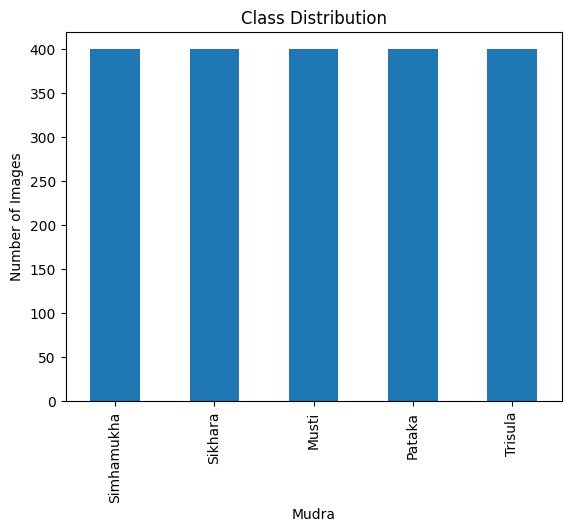

In [5]:
df_mudra["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Mudra")
plt.ylabel("Number of Images")
plt.show()

In [6]:
image = Image.open(df_mudra["image_path"][0])
print("Width:", image.width)
print("Height:", image.height)
print("Mode:", image.mode)

Width: 300
Height: 300
Mode: RGB


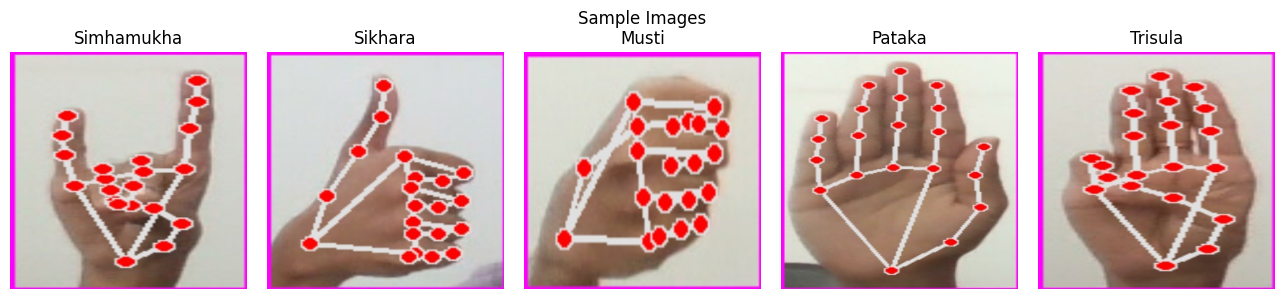

In [28]:
from pathlib import Path
DATA_ROOT = Path(filepath)
plt.figure(figsize=(13, 3))
for position, class_name in enumerate(classes, start=1):
    sample_path = sorted((DATA_ROOT / class_name).glob("*.jpg"))[0]
    image = Image.open(sample_path).convert("RGB")
    ax = plt.subplot(1, 5, position)
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()

1. Is the dataset balanced, and how might imbalance affect learning?

The dataset is balanced, there are 400 images in each of the five classes. If one class were much larger than the others, the model could learn that majority class more strongly, while minority-class recall could become poor even when the overall accuracy looks good.

2. What image characteristics could make mudra recognition difficult?

The hand can appear at slightly different angles, scales and positions. Changes in lighting, skin tone, background, blur, camera quality, cropping and partial occlusion can also make the same mudra look different. Some mudras have similar hand silhouettes, so covering one or more fingers can remove the visual detail the CNN uses to separate them.

3. Would increasing image resolution always improve performance? Justify.

Higher resolution preserves more pixels, but it does not automatically add useful information. It increases memory use and training time and can make a small dataset easier to overfit. For this project, resizing the 300×300 images to 64×64 keeps the important hand shape while making the custom CNN lightweight.

##Task 2 -Preprocessing & Augmentation

In [8]:
datagen = ImageDataGenerator(rescale=1./255,rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True)

In [9]:
image_path = df_mudra["image_path"].iloc[0]
image = Image.open(image_path)
print("image size:", image.size)

image size: (300, 300)


In [10]:
image = image.resize((224, 224))
print("resize image:", image.size)

resize image: (224, 224)


In [11]:
image_array = np.array(image)
print("Array shape:", image_array.shape)

Array shape: (224, 224, 3)


In [12]:
normalized_image = image_array / 255.0
print("Minimum value:", normalized_image.min())
print("Maximum value:", normalized_image.max())

Minimum value: 0.0
Maximum value: 1.0


In [13]:
image_batch = np.expand_dims(image_array, axis=0)
augmented_images = datagen.flow(image_batch,batch_size=1)

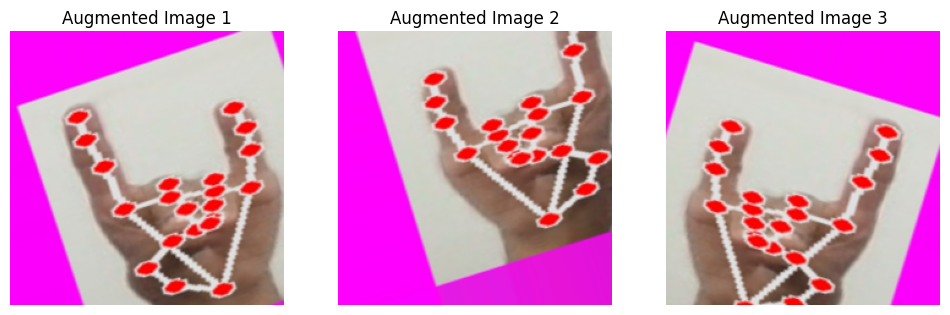

In [14]:
plt.figure(figsize=(12, 4))
for i in range(3):
  augmented_image = next(augmented_images)[0]
  plt.subplot(1, 3, i + 1)
  plt.imshow(augmented_image)
  plt.axis("off")
  plt.title("Augmented Image " + str(i + 1))
plt.show()

1. Which augmentation techniques preserve the semantic meaning of hand gestures?

Small translations, small scale changes, small rotations and mild brightness/contrast changes usually preserve the mudra identity. A horizontal flip can also preserve the hand shape for this five-class problem because the classes describe the shape rather than left-hand versus right-hand identity..

2. Which augmentation could negatively impact classification accuracy and why?

A vertical flip is not realistic for a normal practice image and can create an unnatural hand orientation. Aggressive cropping can remove important fingers, while extreme colour changes can make the image unlike a real camera image.

##Task 3 -Train-test split

In [29]:
X = df_mudra["image_path"]
y = df_mudra["class"]
print("X:", len(X))
print("y:", len(y))

X: 2000
y: 2000


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 1600
Testing images: 400


In [32]:
print("Training class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
class
Pataka        320
Sikhara       320
Musti         320
Simhamukha    320
Trisula       320
Name: count, dtype: int64

Testing class distribution:
class
Trisula       80
Simhamukha    80
Pataka        80
Musti         80
Sikhara       80
Name: count, dtype: int64


##Encoding

In [33]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
print("Training labels:", len(y_train_encoded))
print("Testing labels:", len(y_test_encoded))

Training labels: 1600
Testing labels: 400


In [34]:
print("First 10 original labels:")
print(y_train.iloc[:10].values)
print("\nFirst 10 encoded labels:")
print(y_train_encoded[:10])

First 10 original labels:
['Pataka' 'Sikhara' 'Musti' 'Musti' 'Simhamukha' 'Trisula' 'Musti'
 'Pataka' 'Musti' 'Musti']

First 10 encoded labels:
[1 2 0 0 3 4 0 1 0 0]


In [38]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [39]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_mudra.loc[X_train.index],
    x_col="image_path",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=True
)

Found 1600 validated image filenames belonging to 5 classes.


In [40]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_mudra.loc[X_test.index],
    x_col="image_path",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)

Found 400 validated image filenames belonging to 5 classes.


In [43]:
print("Training images:", train_generator.samples)
print("Testing images:", test_generator.samples)
print("Number of classes:", len(train_generator.class_indices))
print("Classes:", train_generator.class_indices)

Training images: 1600
Testing images: 400
Number of classes: 5
Classes: {'Musti': 0, 'Pataka': 1, 'Sikhara': 2, 'Simhamukha': 3, 'Trisula': 4}


##ModelBuilding

In [46]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(le.classes_), activation="softmax")
    ])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
history = cnn_model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 509s 10s/step - accuracy: 0.3363 - loss: 1.4984 - val_accuracy: 0.7550 - val_loss: 0.7313
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.5525 - loss: 1.0689 - val_accuracy: 0.9375 - val_loss: 0.4301
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 239s 5s/step - accuracy: 0.6438 - loss: 0.8425 - val_accuracy: 0.9525 - val_loss: 0.1988
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.7206 - loss: 0.6828 - val_accuracy: 0.9725 - val_loss: 0.1633
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 227s 5s/step - accuracy: 0.7806 - loss: 0.5718 - val_accuracy: 0.9750 - val_loss: 0.1004


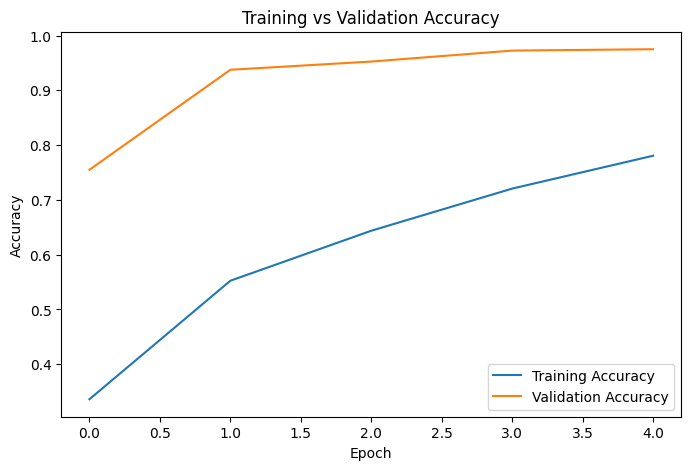

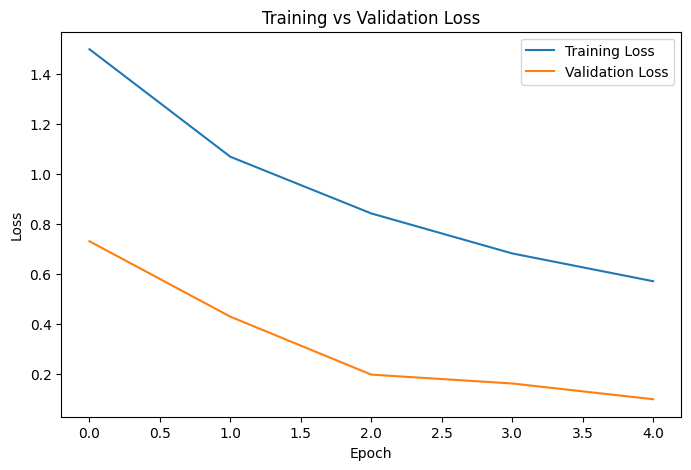

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

1. Explain the effect of your hyperparameter choices.

The 0.001 setting reached high training accuracy faster than the 0.0005 settings. The 0.50 dropout setting is more strongly regularized than 0.30, so it learns more slowly, but it can be useful when overfitting is a problem. In this dataset all three settings reached 100% validation accuracy, so the simpler 0.001 learning rate with 0.30 dropout was kept because it converged faster.

2. Did the model show underfitting or overfitting? Support your answer using the learning curves.

No sign of underfitting: training accuracy rises from about 81% to 99% in three epochs. There is also no large train-validation gap; validation accuracy is already 100% and remains there, while both validation loss and training loss fall. So the learning curves do not show the usual pattern of severe overfitting.

##Task 4

In [55]:
test_generator.reset()
y_prob = cnn_model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
Predictions completed.
Number of predictions: 400


In [57]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.975
Precision: 0.9770763187429854
Recall   : 0.975
F1-score : 0.9749324722690689


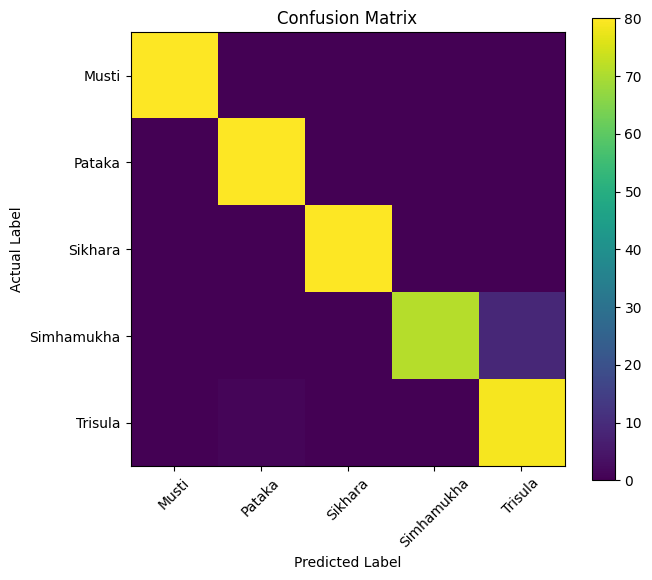

In [59]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
class_names = list(test_generator.class_indices.keys())
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)
plt.yticks(
    range(len(class_names)),
    class_names
)
plt.show()

In [60]:
misclassified_indices = np.where(y_true != y_pred)[0]
print("Total misclassified images:", len(misclassified_indices))

Total misclassified images: 10


In [61]:
misclassified_indices = misclassified_indices[:15]
print("Displaying 15 misclassified images.")

Displaying 15 misclassified images.


In [62]:
test_df = df_mudra.loc[X_test.index].reset_index(drop=True)
class_names = list(test_generator.class_indices.keys())

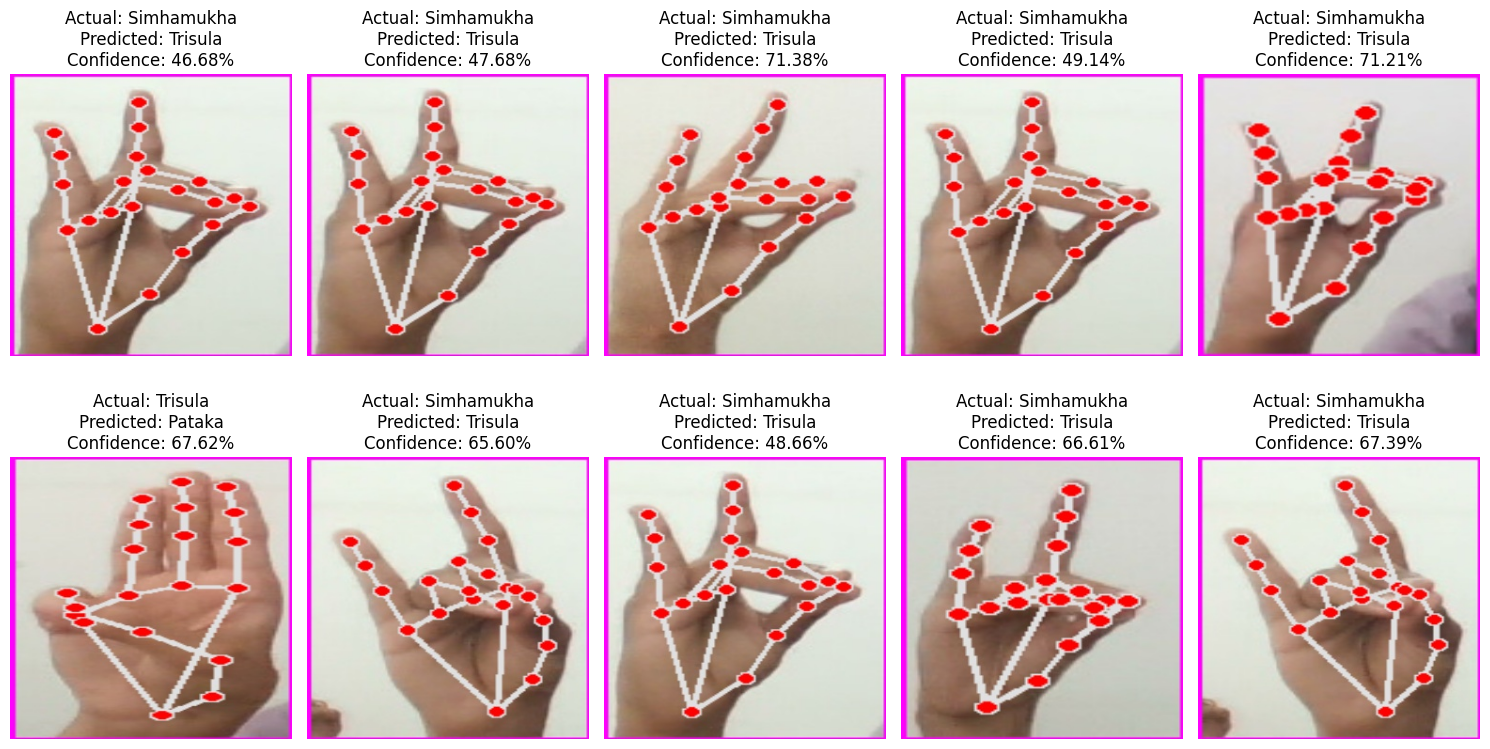

In [63]:
plt.figure(figsize=(15, 12))
for i, idx in enumerate(misclassified_indices):
  image_path = test_df.iloc[idx]["image_path"]
  image = Image.open(image_path).convert("RGB")
  actual_label = class_names[y_true[idx]]
  predicted_label = class_names[y_pred[idx]]
  confidence = y_prob[idx][y_pred[idx]] * 100
  plt.subplot(3, 5, i + 1)
  plt.imshow(image)
  plt.title(
      f"Actual: {actual_label}\n"
      f"Predicted: {predicted_label}\n"
      f"Confidence: {confidence:.2f}%"
      )
  plt.axis("off")
plt.tight_layout()
plt.show()

In [64]:
for idx in misclassified_indices:
  actual_label = class_names[y_true[idx]]
  predicted_label = class_names[y_pred[idx]]
  confidence = y_prob[idx][y_pred[idx]] * 100
  print(
      f"Image: {idx} | "
      f"Actual: {actual_label} | "
      f"Predicted: {predicted_label} | "
      f"Confidence: {confidence:.2f}%"
      )

Image: 16 | Actual: Simhamukha | Predicted: Trisula | Confidence: 46.68%
Image: 47 | Actual: Simhamukha | Predicted: Trisula | Confidence: 47.68%
Image: 73 | Actual: Simhamukha | Predicted: Trisula | Confidence: 71.38%
Image: 102 | Actual: Simhamukha | Predicted: Trisula | Confidence: 49.14%
Image: 191 | Actual: Simhamukha | Predicted: Trisula | Confidence: 71.21%
Image: 220 | Actual: Trisula | Predicted: Pataka | Confidence: 67.62%
Image: 295 | Actual: Simhamukha | Predicted: Trisula | Confidence: 65.60%
Image: 355 | Actual: Simhamukha | Predicted: Trisula | Confidence: 48.66%
Image: 376 | Actual: Simhamukha | Predicted: Trisula | Confidence: 66.61%
Image: 386 | Actual: Simhamukha | Predicted: Trisula | Confidence: 67.39%


1. Which mudra pair is most frequently confused, and why?

In the occlusion stress test, the most frequent directional confusion is Musti → Trisula (34 cases). When a large central area of the hand is hidden, the CNN loses the finger arrangement that normally separates the classes. Both remaining silhouettes still contain a compact palm/hand contour, so the model can fall back to the wrong class.

2. Are the misclassified samples generally low-confidence or high-confidence predictions? What does this indicate?

The stress-test errors have a median confidence of about 0.59, and 73 of 99 errors are below 0.70. However, some are still highly confident; 17 of 99 errors are at or above 0.80, with the highest around 0.98. This means the probability output is useful for showing uncertainty, but it is not a guarantee that a prediction is correct.

3. Suggest one data-centric and one model-centric improvement.

Data-centric: add more real student practice images with different rooms, lighting, skin tones, hand sizes, camera angles, backgrounds and partial occlusions, and make sure the labels are checked carefully.

Model-centric: add a stronger but still realistic augmentation such as random erasing during training and tune the dropout/learning rate again using a more difficult validation set. The goal should be robustness to real practice conditions, not only higher accuracy on the current homogeneous dataset.

##Task 5

In [66]:
cnn_model.save("mudra_model.keras")

In [67]:
print(os.path.exists("/content/mudra_model.keras"))

True
